In [12]:
# Cell 1: Imports and Setup
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [13]:
# Cell 2: Load and preprocess dataset with StandardScaler normalization
def load_preprocess_data(csv_path):
    df = pd.read_csv(csv_path)
    # Assume last column is 'label'
    X = df.iloc[:, :-1].values.astype('float32')
    y = df.iloc[:, -1].values.astype('int')

    print(f"Original pixel value range: min={X.min()}, max={X.max()}")

    # Standardize pixel values (mean=0, std=1)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    print(f"Pixel value range after standardization: min={X.min()}, max={X.max()}")

    # Reshape to (num_samples, 28, 28, 1)
    X = X.reshape(-1, 28, 28, 1)

    return train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Cell 3: Define baseline CNN model with BatchNorm and Dropout
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(28,28,1)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [15]:
# Cell 4: Define flexible CNN variant builder with BatchNorm and Dropout
def build_cnn_variant(num_filters=32, kernel_size=3, num_conv_layers=2, pool_type='max'):
    model = models.Sequential()
    model.add(layers.Input(shape=(28,28,1)))

    for i in range(num_conv_layers):
        filters = num_filters * (2 ** i)
        model.add(layers.Conv2D(filters, (kernel_size, kernel_size), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        if pool_type == 'max':
            model.add(layers.MaxPooling2D((2,2)))
        else:
            model.add(layers.AveragePooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [16]:
# Cell 5: Load data, train baseline, and variants, and collect results
def train_and_evaluate():
    print("Loading and preprocessing data...")
    X_train, X_test, y_train, y_test = load_preprocess_data('cnn_architecture_variant_dataset.csv')
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    print("\nTraining baseline model...")
    baseline_model = build_baseline_model()
    history_baseline = baseline_model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=2)
    test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
    print(f"Baseline Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    results = [{
        'name': 'Baseline',
        'config': {'num_filters': 32, 'kernel_size': 3, 'num_conv_layers': 2, 'pool_type': 'max'},
        'train_acc': history_baseline.history['accuracy'][-1],
        'val_acc': history_baseline.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'train_loss': history_baseline.history['loss'][-1],
        'val_loss': history_baseline.history['val_loss'][-1],
        'history': history_baseline
    }]

    cnn_variants = [
        {'num_filters':16, 'kernel_size':3, 'num_conv_layers':1, 'pool_type':'max'},
        {'num_filters':16, 'kernel_size':5, 'num_conv_layers':1, 'pool_type':'avg'},
        {'num_filters':32, 'kernel_size':3, 'num_conv_layers':2, 'pool_type':'max'},
        {'num_filters':32, 'kernel_size':5, 'num_conv_layers':2, 'pool_type':'avg'},
        {'num_filters':64, 'kernel_size':3, 'num_conv_layers':3, 'pool_type':'max'},
        {'num_filters':64, 'kernel_size':5, 'num_conv_layers':3, 'pool_type':'avg'},
    ]

    for i, cfg in enumerate(cnn_variants):
        print(f"\nTraining variant {i+1}: {cfg}")
        model = build_cnn_variant(**cfg)
        history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=2)
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        train_acc = history.history['accuracy'][-1]
        val_acc = history.history['val_accuracy'][-1]
        train_loss = history.history['loss'][-1]
        val_loss = history.history['val_loss'][-1]

        print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

        results.append({
            'name': f'Variant_{i+1}',
            'config': cfg,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'history': history
        })

    return results


In [17]:
# Cell 6: Plot validation accuracy and loss for all models
def plot_results(results):
    plt.figure(figsize=(14,6))
    for res in results:
        plt.plot(res['history'].history['val_accuracy'], label=res['name'])
    plt.title('Validation Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(14,6))
    for res in results:
        plt.plot(res['history'].history['val_loss'], label=res['name'])
    plt.title('Validation Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.show()


In [18]:
# Cell 7: Create and print summary table of results
def print_summary(results):
    summary = []
    for res in results:
        cfg = res['config']
        summary.append({
            'Model': res['name'],
            'Filters': cfg.get('num_filters', 'N/A'),
            'Kernel Size': cfg.get('kernel_size', 'N/A'),
            'Conv Layers': cfg.get('num_conv_layers', 'N/A'),
            'Pooling': cfg.get('pool_type', 'N/A'),
            'Train Accuracy': round(res['train_acc'],4),
            'Validation Accuracy': round(res['val_acc'],4),
            'Test Accuracy': round(res['test_acc'],4),
            'Train Loss': round(res['train_loss'],4),
            'Validation Loss': round(res['val_loss'],4)
        })

    summary_df = pd.DataFrame(summary)
    print("\nSummary of all models:")
    print(summary_df)


In [20]:
# Cell 8: Run the full pipeline
if __name__ == '__main__':
    results = train_and_evaluate()
    print_summary(results)


Loading and preprocessing data...
Original pixel value range: min=-66.43927001953125, max=66.24423217773438
Pixel value range after standardization: min=-4.923752784729004, max=4.663200855255127
Train samples: 800, Test samples: 200

Training baseline model...
Epoch 1/10
20/20 - 1s - 46ms/step - accuracy: 0.1000 - loss: 2.7737 - val_accuracy: 0.0625 - val_loss: 2.3030
Epoch 2/10
20/20 - 0s - 8ms/step - accuracy: 0.1125 - loss: 2.2925 - val_accuracy: 0.0625 - val_loss: 2.3034
Epoch 3/10
20/20 - 0s - 8ms/step - accuracy: 0.1172 - loss: 2.2830 - val_accuracy: 0.1063 - val_loss: 2.2965
Epoch 4/10
20/20 - 0s - 8ms/step - accuracy: 0.1281 - loss: 2.2727 - val_accuracy: 0.1063 - val_loss: 2.5196
Epoch 5/10
20/20 - 0s - 8ms/step - accuracy: 0.1203 - loss: 2.2630 - val_accuracy: 0.0875 - val_loss: 2.8504
Epoch 6/10
20/20 - 0s - 8ms/step - accuracy: 0.1266 - loss: 2.2451 - val_accuracy: 0.0938 - val_loss: 3.1167
Epoch 7/10
20/20 - 0s - 8ms/step - accuracy: 0.1297 - loss: 2.2597 - val_accuracy: 0

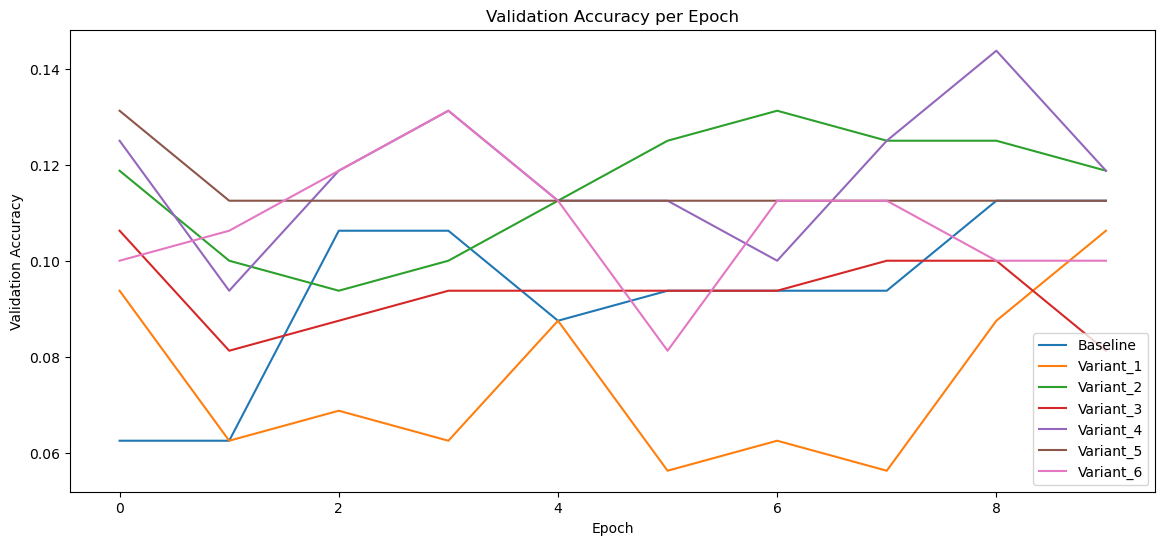

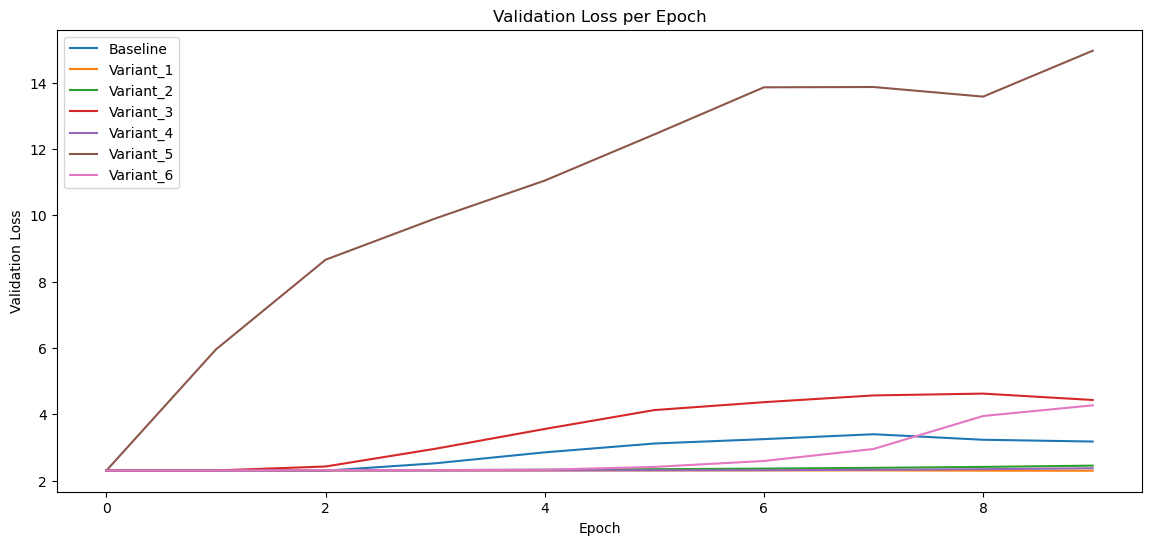

In [21]:
if __name__ == '__main__':
    plot_results(results)

Train samples: 800, Test samples: 200

Training Baseline Model...
Epoch 1/30
20/20 - 1s - 46ms/step - accuracy: 0.3266 - loss: 2.2554 - val_accuracy: 0.4313 - val_loss: 1.0982
Epoch 2/30
20/20 - 0s - 9ms/step - accuracy: 0.3469 - loss: 1.0901 - val_accuracy: 0.3500 - val_loss: 2.0163
Epoch 3/30
20/20 - 0s - 9ms/step - accuracy: 0.3391 - loss: 1.0945 - val_accuracy: 0.3500 - val_loss: 4.3399
Epoch 4/30
20/20 - 0s - 9ms/step - accuracy: 0.3391 - loss: 1.0890 - val_accuracy: 0.3500 - val_loss: 6.7187

Training Variant 1: {'num_filters': 16, 'kernel_size': 3, 'num_conv_layers': 1, 'pool_type': 'max'}
Epoch 1/30
20/20 - 1s - 32ms/step - accuracy: 0.3469 - loss: 1.5901 - val_accuracy: 0.3500 - val_loss: 1.0876
Epoch 2/30
20/20 - 0s - 5ms/step - accuracy: 0.3406 - loss: 1.0933 - val_accuracy: 0.4313 - val_loss: 1.0877
Epoch 3/30
20/20 - 0s - 5ms/step - accuracy: 0.3313 - loss: 1.1077 - val_accuracy: 0.3500 - val_loss: 1.0988
Epoch 4/30
20/20 - 0s - 5ms/step - accuracy: 0.3391 - loss: 1.0878 -

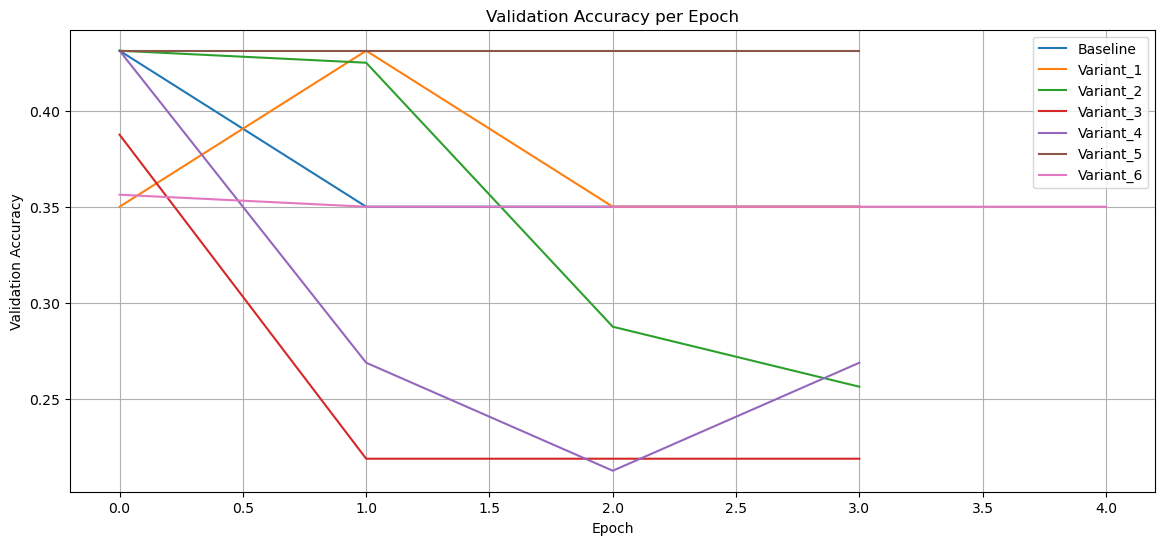

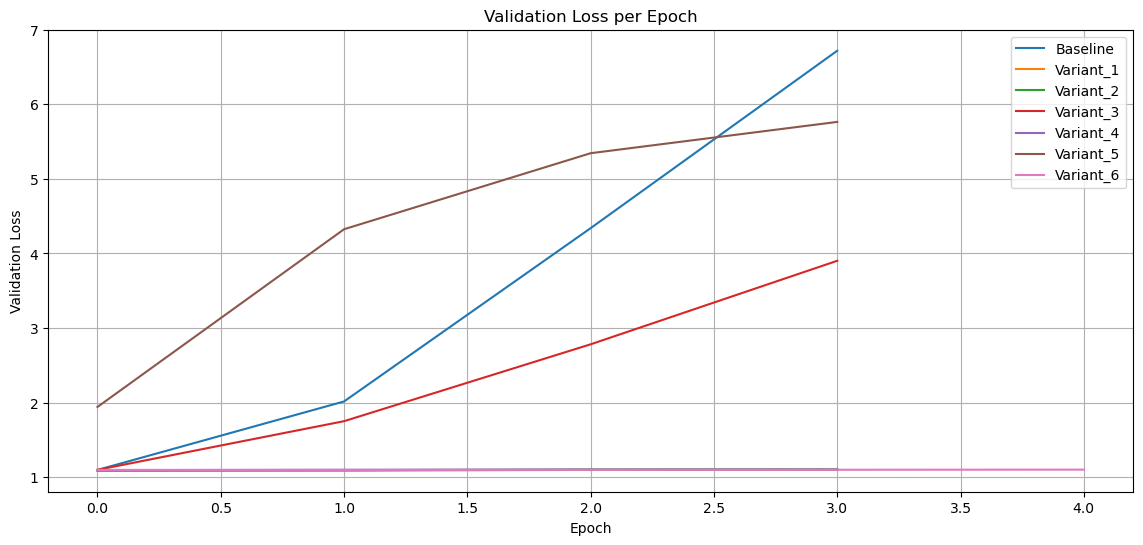


=== Summary of All Models ===
       Model  Filters  Kernel Size  Conv Layers Pooling  Train Accuracy  \
0   Baseline       32            3            2     max          0.3391   
1  Variant_1       16            3            1     max          0.3391   
2  Variant_2       16            5            1     avg          0.7125   
3  Variant_3       32            3            2     max          0.3344   
4  Variant_4       32            5            2     avg          0.4719   
5  Variant_5       64            3            3     max          0.3297   
6  Variant_6       64            5            3     avg          0.3391   

   Validation Accuracy  Test Accuracy  Train Loss  Validation Loss  
0               0.3500          0.315      1.0890           6.7187  
1               0.3500          0.300      1.0878           1.0984  
2               0.2562          0.315      0.7363           1.1063  
3               0.2188          0.300      1.0836           3.9023  
4               0.2688 

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def load_preprocess_data_1000features(csv_path):
    # Load dataset from CSV path passed as argument
    df = pd.read_csv(csv_path)

    # First column is label
    y = df.iloc[:, 0].values.astype('int')
    X = df.iloc[:, 1:].values.astype('float32')

    # Min-Max normalization based on min and max of dataset
    X_min = np.min(X)
    X_max = np.max(X)
    X = (X - X_min) / (X_max - X_min)

    # Reshape input for CNN: pad features to 1024 (32x32), then reshape with 1 channel
    padding = 24  # 1024 - 1000 = 24 zeros to pad
    X_padded = np.pad(X, ((0, 0), (0, padding)), mode='constant')
    X_reshaped = X_padded.reshape(-1, 32, 32, 1)

    return train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

def build_baseline_model_1000features():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 1)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(3, activation='softmax')  # 3 classes output
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def build_cnn_variant_1000features(num_filters=32, kernel_size=3, num_conv_layers=2, pool_type='max'):
    model = models.Sequential()
    model.add(layers.Input(shape=(32, 32, 1)))

    for i in range(num_conv_layers):
        filters = num_filters * (2 ** i)
        model.add(layers.Conv2D(filters, (kernel_size, kernel_size), activation='relu', padding='same'))
        model.add(layers.BatchNormalization())
        if pool_type == 'max':
            model.add(layers.MaxPooling2D((2, 2)))
        else:
            model.add(layers.AveragePooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))  # 3 classes output

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def main_1000features():
    csv_path = 'synthetic_1000x1000pixels_dataset.csv'  # Update with your actual dataset path
    X_train, X_test, y_train, y_test = load_preprocess_data_1000features(csv_path)
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

    early_stop = EarlyStopping(patience=3, restore_best_weights=True)

    print("\nTraining Baseline Model...")
    baseline_model = build_baseline_model_1000features()
    history_baseline = baseline_model.fit(
        X_train, y_train,
        epochs=30,
        validation_split=0.2,
        batch_size=32,
        callbacks=[early_stop],
        verbose=2
    )
    test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)

    results = [{
        'name': 'Baseline',
        'config': {'num_filters': 32, 'kernel_size': 3, 'num_conv_layers': 2, 'pool_type': 'max'},
        'train_acc': history_baseline.history['accuracy'][-1],
        'val_acc': history_baseline.history['val_accuracy'][-1],
        'test_acc': test_acc,
        'train_loss': history_baseline.history['loss'][-1],
        'val_loss': history_baseline.history['val_loss'][-1],
        'history': history_baseline
    }]

    cnn_variants = [
        {'num_filters':16, 'kernel_size':3, 'num_conv_layers':1, 'pool_type':'max'},
        {'num_filters':16, 'kernel_size':5, 'num_conv_layers':1, 'pool_type':'avg'},
        {'num_filters':32, 'kernel_size':3, 'num_conv_layers':2, 'pool_type':'max'},
        {'num_filters':32, 'kernel_size':5, 'num_conv_layers':2, 'pool_type':'avg'},
        {'num_filters':64, 'kernel_size':3, 'num_conv_layers':3, 'pool_type':'max'},
        {'num_filters':64, 'kernel_size':5, 'num_conv_layers':3, 'pool_type':'avg'},
    ]

    for i, cfg in enumerate(cnn_variants):
        print(f"\nTraining Variant {i+1}: {cfg}")
        model = build_cnn_variant_1000features(**cfg)
        history = model.fit(
            X_train, y_train,
            epochs=30,
            validation_split=0.2,
            batch_size=32,
            callbacks=[early_stop],
            verbose=2
        )
        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        train_acc = history.history['accuracy'][-1]
        val_acc = history.history['val_accuracy'][-1]
        train_loss = history.history['loss'][-1]
        val_loss = history.history['val_loss'][-1]

        print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

        results.append({
            'name': f'Variant_{i+1}',
            'config': cfg,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'history': history
        })

    # Plot Validation Accuracy
    plt.figure(figsize=(14, 6))
    for res in results:
        plt.plot(res['history'].history['val_accuracy'], label=res['name'])
    plt.title('Validation Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(14, 6))
    for res in results:
        plt.plot(res['history'].history['val_loss'], label=res['name'])
    plt.title('Validation Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Summary Table
    summary = []
    for res in results:
        cfg = res['config']
        summary.append({
            'Model': res['name'],
            'Filters': cfg.get('num_filters', 'N/A'),
            'Kernel Size': cfg.get('kernel_size', 'N/A'),
            'Conv Layers': cfg.get('num_conv_layers', 'N/A'),
            'Pooling': cfg.get('pool_type', 'N/A'),
            'Train Accuracy': round(res['train_acc'], 4),
            'Validation Accuracy': round(res['val_acc'], 4),
            'Test Accuracy': round(res['test_acc'], 4),
            'Train Loss': round(res['train_loss'], 4),
            'Validation Loss': round(res['val_loss'], 4)
        })

    summary_df = pd.DataFrame(summary)
    print("\n=== Summary of All Models ===")
    print(summary_df)

if __name__ == '__main__':
    main_1000features()
